# Posttest 1 - Eksplorasi Dataset
**Nama:** Rahmat Riyadi

**NIM:** 2409106074

**Dataset:** Medical Cost Personal Dataset (Insurance Dataset)

**Sumber:** https://www.kaggle.com/datasets/mirichoi0218/insurance

Dataset ini berisi data biaya asuransi kesehatan dari beberapa peserta di Amerika Serikat.
Dataset ini punya campuran kolom angka (numerik) dan kolom kategori (object), sehingga sangat cocok untuk saya guanakan untuk latihan eksplorasi data (EDA).

Kolom yang ada di dataset:
- `age` (angka) : umur peserta
- `sex` (kategori) : jenis kelamin
- `bmi` (angka) : Body Mass Index
- `children` (angka) : jumlah anak/tanggungan
- `smoker` (kategori) : status merokok
- `region` (kategori) : wilayah tempat tinggal
- `charges` (angka) : biaya asuransi yang dikenakan (target label)


In [25]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## 1. Load Dataset
Dataset diambil langsung dari link mirror GitHub, karena isinya sama persis dengan dataset aslinya di Kaggle. Dengan cara ini notebook bisa langsung dijalankan tanpa perlu setting API key Kaggle dulu.


In [26]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2A. Informasi Umum Dataset
Bagian ini menampilkan jumlah record (baris), jumlah attribute (kolom), nama-nama attribute, dan jumlah attribute yang bertipe angka.

In [27]:
jumlah_record = df.shape[0]
jumlah_attribute = df.shape[1]
nama_attribute = df.columns.tolist()
attribute_numerik = df.select_dtypes(include=np.number).columns.tolist()

print("Jumlah record:", jumlah_record)
print("Jumlah attribute:", jumlah_attribute)
print("Nama-nama attribute:", nama_attribute)
print("Jumlah attribute bertipe angka:", len(attribute_numerik))
print("Nama attribute bertipe angka:", attribute_numerik)


Jumlah record: 1338
Jumlah attribute: 7
Nama-nama attribute: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Jumlah attribute bertipe angka: 4
Nama attribute bertipe angka: ['age', 'bmi', 'children', 'charges']


### 2B. Pengecekan Kualitas Data (Missing Values & Duplikat)
Sebelum melakukan analisis lebih jauh, penting untuk memastikan bahwa dataset tidak memiliki nilai yang kosong (*missing values*) dan tidak ada baris data yang ganda (*duplicate records*).

In [28]:
print("Jumlah Missing Values per Attribute:")
print(df.isnull().sum())
print("-" * 30)

jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah Record Duplikat: {jumlah_duplikat}")

Jumlah Missing Values per Attribute:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
------------------------------
Jumlah Record Duplikat: 1


In [29]:
print("Tampilan data yang duplikat:")
display(df[df.duplicated(keep=False)])
df.drop_duplicates(inplace=True)

# Memastikan jumlah record terbaru
print(f"\nJumlah record setelah duplikat dihapus: {df.shape[0]}")

Tampilan data yang duplikat:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631



Jumlah record setelah duplikat dihapus: 1337


## 3. Statistik Deskriptif Attribute Numerik
Menampilkan rata-rata (mean), standar deviasi (std), nilai minimum, nilai maksimum, Q1 (kuartil 1), Q2 (median), dan Q3 (kuartil 3) untuk setiap attribute bertipe angka.

In [30]:
df_numerik = df[attribute_numerik]

statistik = pd.DataFrame({
    "Mean": df_numerik.mean(),
    "Std Dev": df_numerik.std(),
    "Min": df_numerik.min(),
    "Q1 (25%)": df_numerik.quantile(0.25),
    "Q2/Median (50%)": df_numerik.quantile(0.50),
    "Q3 (75%)": df_numerik.quantile(0.75),
    "Max": df_numerik.max(),
})

statistik


,Mean,Std Dev,Min,Q1 (25%),Q2/Median (50%),Q3 (75%),Max
age,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


## 4. 10 Record Pertama
Bagian ini cuma menampilkan kolom yang bertipe angka aja, karena tujuannya buat lihat contoh nilai numerik di dataset. Ditambah juga 10 record terakhir (`tail`), biar kelihatan apakah ada perbedaan pola di awal dan akhir data.

In [37]:
#Dari atas
df_numerik.head(10)


,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
5,31,25.740,0,3756.62160
6,46,33.440,1,8240.58960
7,37,27.740,3,7281.50560
8,37,29.830,2,6406.41070
9,60,25.840,0,28923.13692


In [36]:
# dari bawah
df_numerik.tail(10)

,age,bmi,children,charges
1328,23,24.225,2,22395.74424
1329,52,38.600,2,10325.20600
1330,57,25.740,2,12629.16560
1331,23,33.400,0,10795.93733
1332,52,44.700,3,11411.68500
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500
1337,61,29.070,0,29141.36030


## 5. Jumlah Label pada Attribute Bertipe Object
Setiap attribute yang bertipe object (kategori) dicek jumlah label unik beserta jumlah data di tiap labelnya.

In [32]:
attribute_object = df.select_dtypes(include="object").columns.tolist()
print("Attribute bertipe object:", attribute_object)

for col in attribute_object:
    print(f"\nAttribute '{col}' punya {df[col].nunique()} label unik:")
    print(df[col].value_counts())


Attribute bertipe object: ['sex', 'smoker', 'region']

Attribute 'sex' punya 2 label unik:
sex
male      675
female    662
Name: count, dtype: int64

Attribute 'smoker' punya 2 label unik:
smoker
no     1063
yes     274
Name: count, dtype: int64

Attribute 'region' punya 4 label unik:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## 6. Visualisasi Data
### Visualisasi 1: Histogram Distribusi Umur dan Biaya Asuransi
Histogram dipilih karena cocok buat lihat sebaran (distribusi) satu variabel numerik, dalam hal ini umur (`age`) dan biaya asuransi (`charges`). Dari sini bisa kelihatan apakah datanya menyebar merata atau nge-cluster di nilai tertentu.

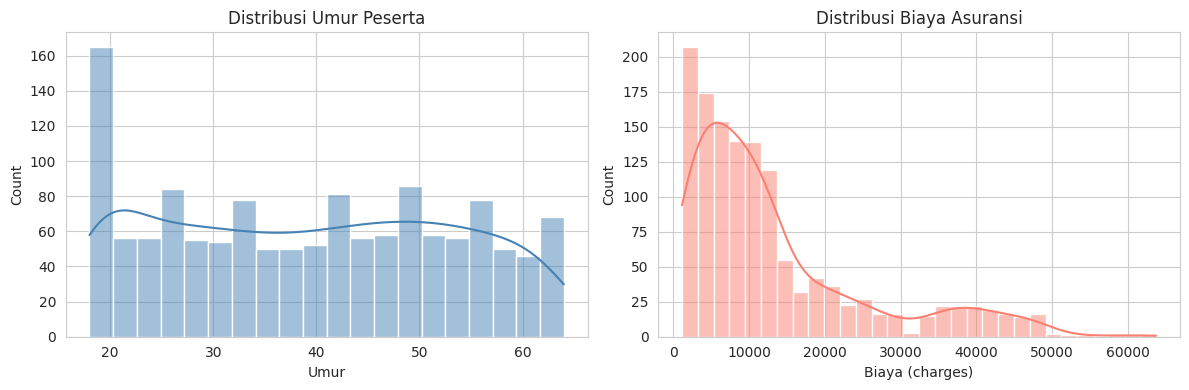

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["age"], bins=20, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribusi Umur Peserta")
axes[0].set_xlabel("Umur")

sns.histplot(df["charges"], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribusi Biaya Asuransi")
axes[1].set_xlabel("Biaya (charges)")

plt.tight_layout()
plt.show()


### Visualisasi 2: Boxplot Biaya Asuransi Berdasarkan Status Merokok
Boxplot dipakai untuk membandingkan sebaran biaya asuransi (`charges`) antara peserta yang merokok dan tidak. Dari grafik ini langsung kelihatan perbedaan median, rentang data, sampai ada tidaknya *outlier* di masing-masing kelompok.


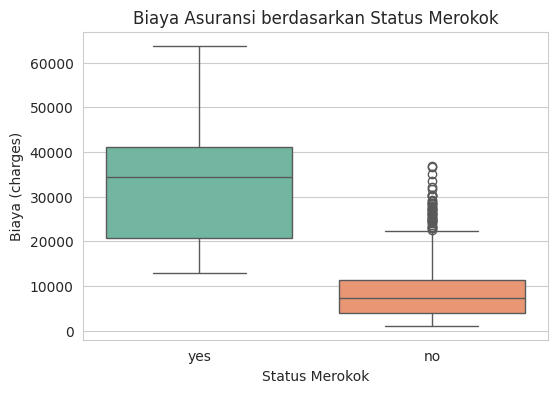

In [40]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="smoker", y="charges", hue="smoker", data=df, palette="Set2", legend=False)
plt.title("Biaya Asuransi berdasarkan Status Merokok")
plt.xlabel("Status Merokok")
plt.ylabel("Biaya (charges)")
plt.show()

## Visualisasi 3: Hubungan Umur dan Biaya Asuransi berdasarkan Status Merokok
Scatter plot dipilih karena cocok untuk lihat hubungan dua variabel numerik sekaligus, yaitu umur dan biaya asuransi. Titik-titiknya dibedakan warnanya berdasarkan status merokok, jadi bisa keliatan apakah pola hubungan umur-biaya ini beda antara perokok dan yang bukan.

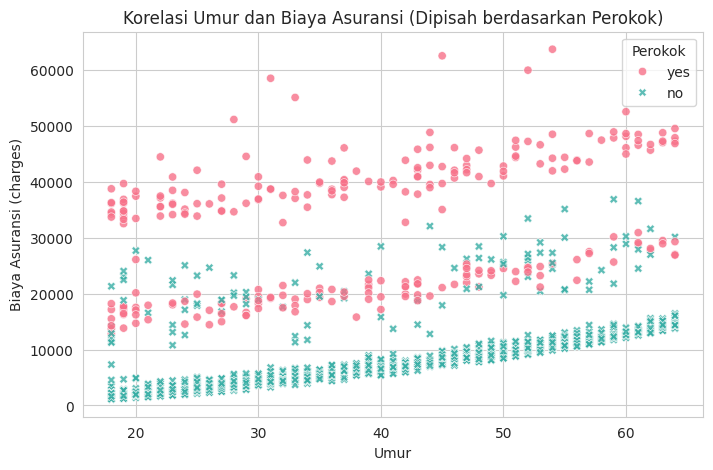

In [41]:
plt.figure(figsize=(8, 5))
# Scatter plot untuk melihat korelasi 3 variabel: umur, biaya, dan perokok
sns.scatterplot(x="age", y="charges", hue="smoker", style="smoker", data=df, palette="husl", alpha=0.8)
plt.title("Korelasi Umur dan Biaya Asuransi (Dipisah berdasarkan Perokok)")
plt.xlabel("Umur")
plt.ylabel("Biaya Asuransi (charges)")
plt.legend(title="Perokok")
plt.show()


## 7. Korelasi Antar Attribute Numerik (Heatmap)
Heatmap dipakai untuk melihat seberapa kuat hubungan (korelasi) antar attribute bertipe angka. Nilai mendekati 1 atau -1 menunjukkan hubungan yang kuat, sedangkan nilai mendekati 0 menunjukkan hubungan yang lemah.

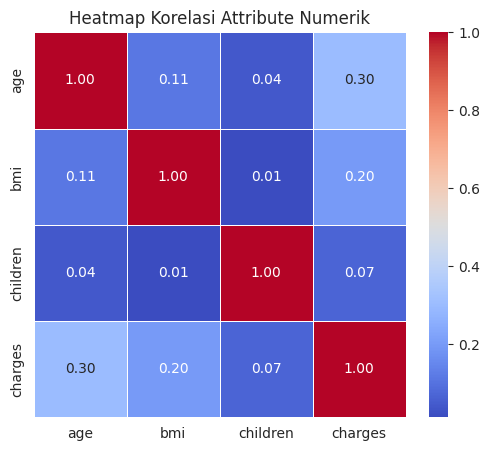

In [35]:
plt.figure(figsize=(6, 5))
korelasi = df_numerik.corr()
sns.heatmap(korelasi, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Attribute Numerik")
plt.show()


## 8. Kesimpulan Eksplorasi

Beberapa hal yang bisa disimpulkan dari eksplorasi dataset ini:

* **Kualitas Data:** Secara keseluruhan data sudah bersih (tidak ada *missing values*), namun ditemukan **1 record duplikat** yang telah dihapus untuk menghindari bias analisis. Total data bersih yang digunakan adalah 1337 record.
* **Distribusi Data:** Rata-rata biaya asuransi (`charges`) cukup tinggi dan sebarannya tidak merata (terdapat *outliers* / nilai yang jauh lebih besar dari rata-rata).
* **Pengaruh Rokok (Bivariat):** Dari *boxplot*, terlihat sangat jelas bahwa peserta yang merokok cenderung membayar biaya asuransi jauh lebih tinggi dibandingkan yang tidak merokok.
* **Korelasi Variabel Numerik:** Dari *heatmap*, `age` dan `charges` memiliki korelasi positif (semakin tua, biaya cenderung semakin naik). `bmi` juga memiliki korelasi positif meski tidak sekuat `age`.
* **Interaksi Multivariat (Umur, Biaya, & Rokok):** Dari *scatter plot*, dapat disimpulkan bahwa kombinasi antara bertambahnya umur dan kebiasaan merokok menghasilkan lonjakan biaya asuransi yang paling ekstrim. Perokok di usia muda bahkan bisa membayar lebih mahal daripada non-perokok di usia tua.